In [27]:
## Begin with import statements from Kevin:
import numpy as np
import scipy
from matplotlib.pyplot import *
from matplotlib import pyplot as plt
#from scipy.special import erf
import math
#from scipy.optimize import least_squares
#from scipy.optimize import curve_fit


In [2]:
## Functions for Index Shift and Phase Shift from total timing difference:
# Each time index is 2.56us, we want total time/2.56us to give us the number of indices, ignoring remainder.
# Each phase shift depends on frequency... each 2pi occurs on timescale 1/f, want remainder to find phase shift

def Index_Shift_From_Time(time_array):
    return (time_array/(2.56e-6)).astype(int)
    
def Phase_Shift_From_Time(time_array,frequency):
    return time_array/(frequency**-1.0)#%(2*np.pi)

## Assume no lag, irrelevant for now

FS_Lag=0.0#typdist/SOL

FE_Lag=0.0#100.0/(0.85*SOL)


## DEFN the Gauss Fit function:
def Gauss(x,a,x0,sigma,k):
    return a*np.exp(-(x-x0)**2.0/(2.0*sigma**2.0))+k

In [ ]:
# Can we measure phase at XXm/s flight speed, and some cable lag?

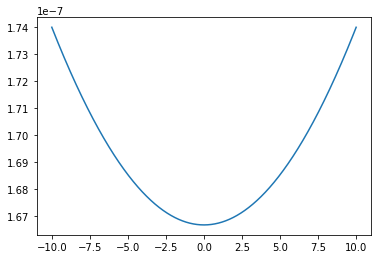

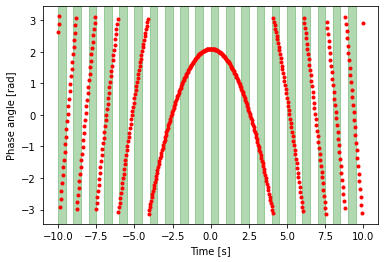

In [60]:
freq = 670E6
cable_length = 0#90 #m
drone_x = np.arange(-15,15,0.001) # m
drone_h = 50
drone_speed = 1.5 #mps
secs = drone_x/drone_speed
flight_dist = np.sqrt(drone_x**2 + drone_h**2)
flight_delay = (cable_length + flight_dist)/3E8

# make this correspond to time
times = drone_x/drone_speed

plt.plot(times,flight_delay)
plt.show()

# now turn flight delay into phase
phase = -1.j*flight_delay*freq*2*np.pi
sig = np.exp(phase)
angle_sig = np.angle(sig)


# sample
nsamps = int((times[-1] - times[0])/42E-3)
samples = times[0] + 42E-3*np.arange(nsamps) # 42ms cadence data

sampled_sig_func = scipy.interpolate.interp1d(times,angle_sig)
sampled_sig = sampled_sig_func(samples)


#plt.plot(times,angle_sig)
plt.plot(samples,sampled_sig,'r.')
for i in np.arange(times[0],times[-1],1):
    plt.axvspan(i, i+0.5,color='green',alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Phase angle [rad]')
plt.show()

# 2pi or no 2pi in the phase factor?: no 2 pi

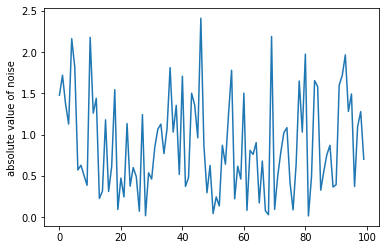

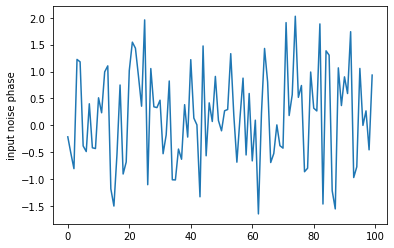

0.8867855471052871


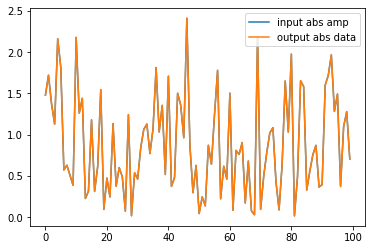

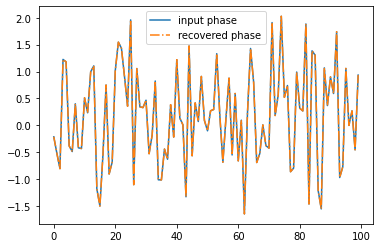

In [3]:
# Understand the 2 pi factors in phase recovery 
# This won't work for amplitude, which should be positive in Euler identity definition

pp = np.abs(np.random.normal(0,1,100))
phase=np.random.normal(0,1,100)

plt.plot(pp)
plt.ylabel('absolute value of noise')
plt.show()

plt.plot(phase)
plt.ylabel('input noise phase')
plt.show()
print(np.std(phase))

dd = pp*np.exp(-1.0j*phase) # data, complex

rephase = -1.*np.angle(dd)
#rephase = -1.0*np.arctan2(dd.imag,dd.real)

plt.plot(pp,label='input abs amp')
plt.plot(np.abs(dd), label='output abs data')
plt.legend()
plt.show()

plt.plot(phase,label='input phase')
plt.plot(rephase,ls='-.',label='recovered phase')
plt.legend()
plt.show()

# This means np.angle strictly recovers the input phase, no 2pi

# What is the jitter inferred from phase, compared to input jitter?

In [4]:
## I want to input a jitter value (say from Kalyani), and plot phase (recovery?) vs Gt

## This run is 50 jitters, some gains [hyperbolic distribution], some iterations, input power 0, 4 int periods...
## Select fixed params that dictate run properties:
fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=1.0
iteration_space=np.arange(100)
jitter_space=np.hstack((np.array([0]),np.linspace(1e-10,1e-9,10)))
gain_space=(np.linspace(0.01,1.1,12)**2.0)


## Define parameter arrays that we want to pull out for each jitter we test:
input_phase=np.zeros((len(jitter_space),len(gain_space),len(iteration_space)))
## Unquantized (f) correlations:
nq_max_ind_auto=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_ind_cross=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_mag_auto_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_auto_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)

signal=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term_off=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))

for i,iteration in enumerate(iteration_space):
    for g,gain in enumerate(gain_space):
        f_signal=signal[i]
        f_signal_on=(gain*signal[i])+noise_term[i]
        f_signal_off=noise_term_off[i]
        for j,jitter in enumerate(jitter_space):
            print('Iteration:{}/{}, Gain:{}/{}, Jitter:{}/{}    '.format(i+1,len(iteration_space),g+1,len(gain_space),j+1,len(jitter_space)),end='\r')
            ## Draw a sample to populate the jitter array and construct index shift/phase:
            simtimearr=(np.ones(t_length)*(FS_Lag+FE_Lag))+np.random.normal(0,jitter,t_length)
            index_shift=int(np.nanmedian(Index_Shift_From_Time(simtimearr)))
            phase_rads=Phase_Shift_From_Time(simtimearr,fman)
            input_phase[j,g,i]=np.nanmean(phase_rads)
            phase_array=np.exp(-1.0j*phase_rads)
            #phase_array=np.exp(-1.0j*2.0*np.pi*phase_rads)
            ## create the f and q arrays:
            f_signal_on_ps=np.roll(phase_array*f_signal_on,index_shift)
            f_signal_off_ps=np.roll(phase_array*f_signal_off,index_shift)
            ## Select the scaling
            ## Perform correlations (unquantized):
            nq_auto_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal_on_ps)))
            nq_auto_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal_off_ps)))
            nq_cross_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal)))
            nq_cross_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal)))
            ## Populate loop auto variables (unquantized):
            nq_max_mag_auto_on[j,g,i]=nq_auto_corr_on_ps[0]
            nq_max_mag_auto_off[j,g,i]=nq_auto_corr_off_ps[0]
            nq_max_mag_cross_on[j,g,i]=nq_cross_corr_on_ps[0]
            nq_max_mag_cross_off[j,g,i]=nq_cross_corr_off_ps[0]                


using this gain:  0.09441652892561986


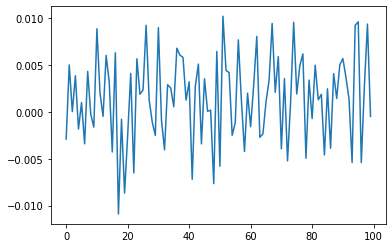

recovered jitter value from phase:  3.995829535336073e-11
compared to input jitter value:  3.0000000000000005e-10


In [234]:
# for a given jitter and gain, plot the phase angle and print the inferred timing jitter from the data
j = 3
g = 3
print('using this gain: ',gain_space[g])
plt.plot(-np.angle(nq_max_mag_cross_on[j,g,:])/(2*np.pi))
plt.show()
print('recovered jitter value from phase: ',(1/fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[j,g,:])))
print('compared to input jitter value: ', jitter_space[j])

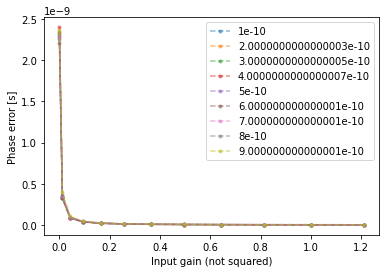

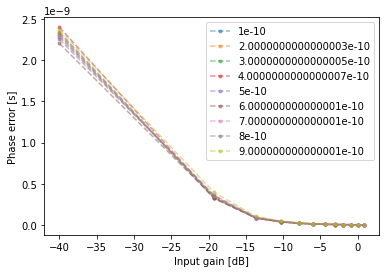

In [6]:
for j,jit in enumerate(jitter_space[1:-1]):
    plt.plot(gain_space,(1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[j,:,:]),axis=1),'.--',alpha=0.5,label=jit)
plt.ylabel('Phase error [s]')
plt.xlabel('Input gain (not squared)')
#plt.xlim(0,0.01)
#plt.ylim(0.4E-11,4E-10)
plt.legend()
plt.show()

for j,jit in enumerate(jitter_space[1:-1]):
    plt.plot(10*np.log10(gain_space),(1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[j,:,:]),axis=1),'.--',alpha=0.5,label=jit)
plt.ylabel('Phase error [s]')
plt.xlabel('Input gain [dB]')
#plt.xlim(0,0.01)
#plt.ylim(0.4E-11,4E-10)
plt.legend()
plt.show()

/var/folders/kq/gm65xyys6p58_kzskv0cq_sc0000gq/T/ipykernel_29452/3070088725.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(jitter_space*1e9,((1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1))/jitter_space,'.--',label=gain)


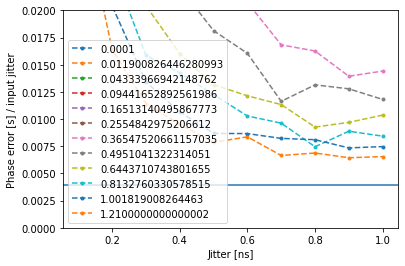

/var/folders/kq/gm65xyys6p58_kzskv0cq_sc0000gq/T/ipykernel_29452/3070088725.py:20: RuntimeWarning: divide by zero encountered in divide
  (np.sqrt(t_length))*((1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1))/jitter_space,


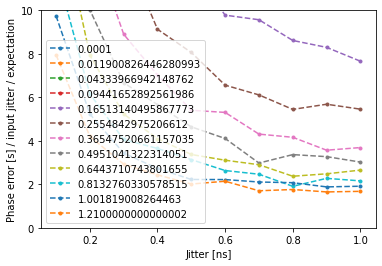

In [7]:
# plot ratio of output time jitter to input time jitter vs gain

for g, gain in enumerate(gain_space):
    plt.plot(jitter_space*1e9,((1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1))/jitter_space,'.--',label=gain)
plt.ylabel('Phase error [s] / input jitter')
plt.xlabel('Jitter [ns]')
plt.axhline(1./np.sqrt(t_length))
#plt.xlim(0.1,0.4)
plt.ylim(0,0.02)
plt.legend()
plt.show()

# Tested, and found that this ratio does change with number of integrations considered, so 
# input jitter /sqrt(t_length) is the expectation overall
# which means in this ratio, 1/sqrt(tlength) in this particular plot


for g, gain in enumerate(gain_space):
    plt.plot(jitter_space*1e9,
             (np.sqrt(t_length))*((1./fman)*np.nanstd(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1))/jitter_space,
             '.--',label=gain)
plt.ylabel('Phase error [s] / input jitter / expectation')
plt.xlabel('Jitter [ns]')
#plt.axhline(1./np.sqrt(t_length))
#plt.xlim(0.1,0.4)
plt.ylim(0,10)
plt.legend()
plt.show()

In [ ]:
# generally the recovered jitter from phase is smaller than input jitter
# limiting case seems to be 2*sqrt(t_length)

# Normalization investigation

In [235]:
# check parseval's theorem
# This is to check numpy's normalization

l = 10000
s=abs(np.random.normal(0,1.0,l))

a = 1.0
x = sum(s**2)
fx = (1/l)*sum(np.abs(np.fft.fft(s))**2)
print(x,a*fx)

# this matches with no additional normalization

# should be able to recover the statistics of the variance
# with Parseval normalization

s = np.random.normal(0,1.0,l)
print(np.std(s),np.var(s))

fs = np.fft.fft(s)
print((1/l)*np.var(fs))
print((1/np.sqrt(l))*np.std(fs))

# yup - input was 1, output is 1

# check correlation result
corr=np.fft.ifft(np.fft.fft(s)*np.conjugate(np.fft.fft(s)))
print((1/l)*corr[0])
# all variance lives in the 0 bin, recover with 1/N normalization
# must be variance because fft is squared
# this means would recover stddev with a 1/sqrt(N) normalization

9877.997669303313 9877.99766930322
0.9856102858848688 0.9714276356420527
0.9713829076018716
0.9855875950933389
(0.9715134557119848+4.1434332127774453e-19j)


(100, 65536)


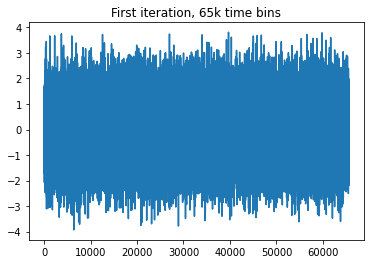

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


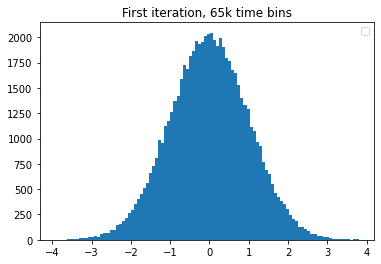

(100, 65536)


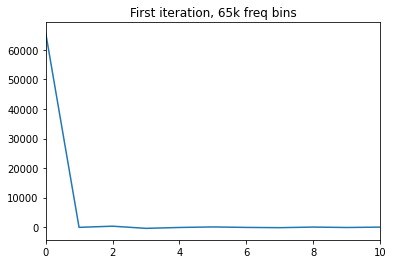

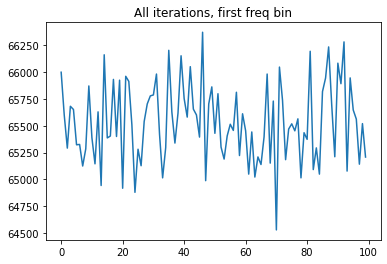

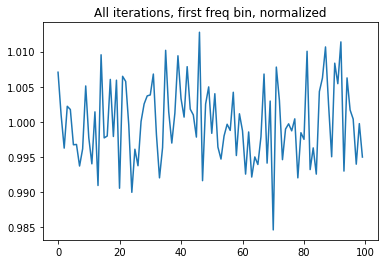

mean variance with  100  iterations:  (0.9999187125748787+0j)
error (std) on the variance with  100  iterations:  0.00556177080530426
(200, 65536)
(200, 65536)
mean variance with 200 iterations:  (0.9999593453803592+1.828794718658157e-21j)
error (std) on the variance with 200  0.005590128630268641
(10, 65536)
(10, 65536)
mean variance with 10 iterations:  (1.0002431555195261+2.964013505842248e-20j)
error (std) on the variance with 10  0.005097101605309686


In [142]:
## Lets normalize a real-only signal:

signal=np.random.normal(0,inputpower,(len(iteration_space),t_length))
print(signal.shape) # 100, 65k

plt.title('First iteration, 65k time bins')
plt.plot(signal[0,:])
plt.show()

plt.title('First iteration, 65k time bins')
plt.hist(signal[0,:],bins=100)
plt.legend()
plt.show()

corr=np.fft.ifft(np.fft.fft(signal)*np.conjugate(np.fft.fft(signal)))
print(corr.shape)

plt.title('First iteration, 65k freq bins')
plt.plot(corr[0,:])
plt.xlim(0,10)
plt.show()

plt.title('All iterations, first freq bin')
plt.plot(corr[:,0])
plt.show()

plt.title('All iterations, first freq bin, normalized')
plt.plot(corr[:,0]/65536)
plt.show()

# What is the mean variance/stddev:
print('mean variance with ', len(iteration_space), ' iterations: ',np.average(corr[:,0]/65536))

print('error (std) on the variance with ', len(iteration_space), ' iterations: ',np.std(corr[:,0]/65536))

# 200 iterations
signal=np.random.normal(0,inputpower,(200,t_length))
print(signal.shape) # 200, 65k

corr=np.fft.ifft(np.fft.fft(signal)*np.conjugate(np.fft.fft(signal)))
print(corr.shape)

# What is the mean variance/stddev:
print('mean variance with 200 iterations: ',np.average(corr[:,0]/65536))

print('error (std) on the variance with 200 ',np.std(corr[:,0]/65536))

# 10 iterations
signal=np.random.normal(0,inputpower,(10,t_length))
print(signal.shape) # 500, 65k

corr=np.fft.ifft(np.fft.fft(signal)*np.conjugate(np.fft.fft(signal)))
print(corr.shape)

# What is the mean variance/stddev:
print('mean variance with 10 iterations: ',np.average(corr[:,0]/65536))

print('error (std) on the variance with 10 ',np.std(corr[:,0]/65536))

# as in the Parseval case, i recover the variance from the signal in the first bin
# have to normalize the variance by 1/N

(1000,)


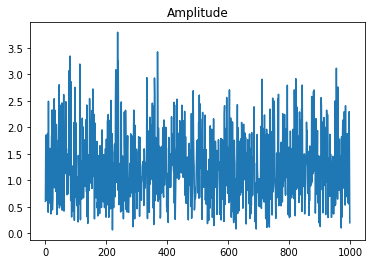

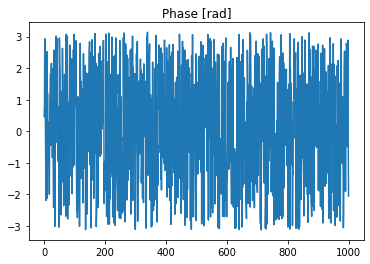

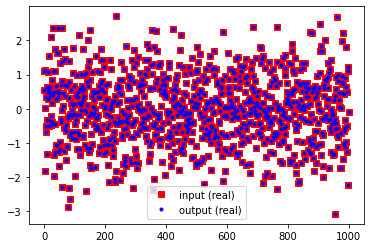

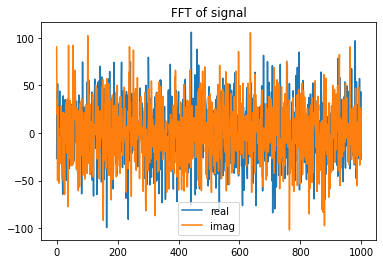

first bin:  (1950.445017467937+5.051668975488213e-16j)


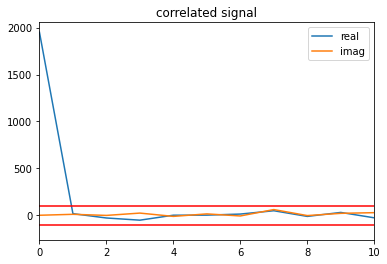

[ 1.95044502e+03+5.05166898e-16j  1.69294243e+01+1.00766512e+01j
 -2.90291854e+01-1.59767696e+00j -5.23431663e+01+2.31243825e+01j
  5.31681355e-01-1.20384168e+01j  1.32792510e+00+1.45821982e+01j
  1.27982496e+01-7.47505353e+00j  4.81679245e+01+6.06642422e+01j
 -1.22206669e+01-3.29872681e+00j  3.01824727e+01+2.04175462e+01j]
(0.9752225087339685+2.5258344877441065e-19j)


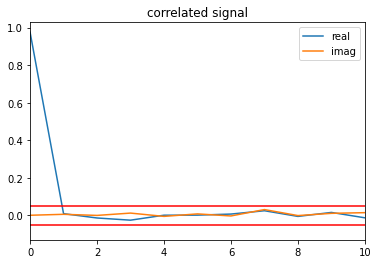

real and imag of correlated signal:  [ 9.75222509e-01+2.52583449e-19j  8.46471213e-03+5.03832558e-03j
 -1.45145927e-02-7.98838481e-04j -2.61715831e-02+1.15621913e-02j
  2.65840678e-04-6.01920840e-03j  6.63962552e-04+7.29109909e-03j
  6.39912479e-03-3.73752676e-03j  2.40839622e-02+3.03321211e-02j
 -6.11033345e-03-1.64936340e-03j  1.50912364e-02+1.02087731e-02j]
resulting angle of corr signal:  [ 2.59000840e-19  5.36893859e-01 -3.08661120e+00  2.72559198e+00
 -1.52665962e+00  1.47998200e+00 -5.28622738e-01  8.99719426e-01
 -2.87794590e+00  5.94759056e-01]


In [270]:
# what is the equivalent for phase? First, a single iteration
signal=np.random.normal(0,inputpower,1000)+1.0j*np.random.normal(0,inputpower,1000)
print(signal.shape)

r = np.abs(signal)
phase = np.angle(signal)

plt.plot(r)
plt.title('Amplitude')
plt.show()
plt.plot(phase)
plt.title('Phase [rad]')
plt.show()

plt.plot(signal.real,'rs',label='input (real)')
plt.plot(np.real(r*np.exp(1.j*phase)),'b.',label='output (real)')
plt.legend()
plt.show()

fs = np.fft.fft(signal)
plt.title('FFT of signal')
plt.plot(fs.real,label='real')
plt.plot(fs.imag,label='imag')
plt.legend()
plt.show()

# Now correlate and see what happens
corr=np.fft.ifft(np.fft.fft(signal)*np.conjugate(np.fft.fft(signal)))
print('first bin: ',corr[0])

plt.title('correlated signal')
plt.plot(corr.real,label='real')
plt.plot(corr.imag,label='imag')
plt.xlim(0,10)
plt.legend()
plt.axhline(-100,color='red')
plt.axhline(100,color='red')
plt.show()

# the real component of the first bin contains the majority of power
# The levels at other bins are small, and the same level between real and imag
# because we conjugate the fft and multiply, the real component contains
# most of the power. This will also make the angle a lot smaller than the input angle

print(corr[0:10])
print(corr[0]/(2*len(signal))) 
# need additional factor of 2,
# presumably because it is absorbing variance from both real+imag into real

plt.title('correlated signal')
plt.plot(corr.real/(2*len(signal)),label='real')
plt.plot(corr.imag/(2*len(signal)),label='imag')
plt.xlim(0,10)
plt.legend()
plt.axhline(-100/(2*len(signal)),color='red')
plt.axhline(100/(2*len(signal)),color='red')
plt.show()

print('real and imag of correlated signal: ',corr[0:10]/(2*len(signal))) 
print('resulting angle of corr signal: ',np.angle(corr[0:10]))

(2088.1179037790807-2.339856416784363e-15j)


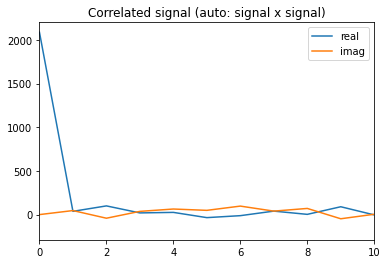

(1.0440589518895405-1.1699282083921817e-18j)
(1000,)


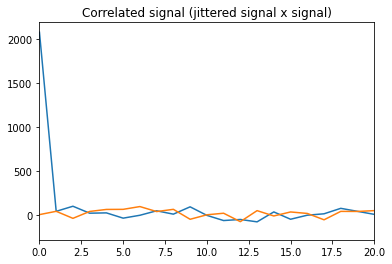

corr signal over 2*N:  [ 1.03918006+0.00108387j  0.01987168+0.01993438j  0.0487738 -0.02008666j
  0.00923489+0.01918326j  0.01095726+0.03057633j -0.01899979+0.03110069j
 -0.0025978 +0.04694114j  0.0228712 +0.0184627j   0.00375124+0.03117038j
  0.04539559-0.02543055j]
corr angle:  [ 1.04300336e-03  7.86973427e-01 -3.90665478e-01  1.12213612e+00
  1.22669548e+00  2.11920086e+00  1.62608159e+00  6.79144192e-01
  1.45102611e+00 -5.10639608e-01]


In [271]:
signal=np.random.normal(0,1.0,1000)+1.0j*np.random.normal(0,1.0,1000)
# now add an additional jitter phase
jit = np.exp(-1.0j*np.random.normal(0,0.1,1000))

jitsig = signal*jit

# first, autocorrelation of jittered signal
corr=np.fft.ifft(np.fft.fft(jitsig)*np.conjugate(np.fft.fft(jitsig)))
print(corr[0])

plt.title('Correlated signal (auto: signal x signal)')
plt.plot(corr.real,label='real')
plt.plot(corr.imag,label='imag')
plt.xlim(0,10)
plt.legend()
plt.show()

print(corr[0]/(2*len(signal))) 

# now correlate
corr=np.fft.ifft(np.fft.fft(jitsig)*np.conjugate(np.fft.fft(signal)))
print(corr.shape)

plt.title('Correlated signal (jittered signal x signal)')
plt.plot(corr.real,label='real')
plt.plot(corr.imag,label='imag')
plt.xlim(0,20)
plt.show()

print('corr signal over 2*N: ',corr[0:10]/(2*len(signal))) 
# The larger the jitter, the more corr[0] diverges from the variance expectation (1.0)

# similar results as above, except the 0th bin has
# similar value as the other bins for the imaginary component
print('corr angle: ',np.angle(corr[0:10])) 

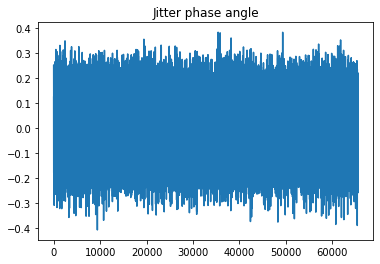

0.09976078106531269
0.09341006297787727


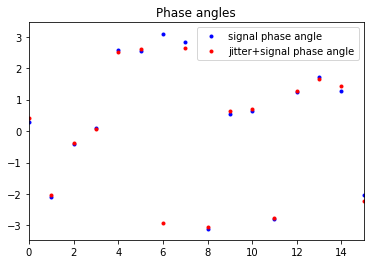

(100, 65536)


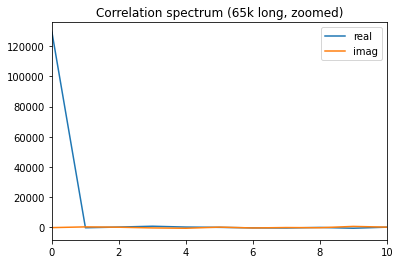

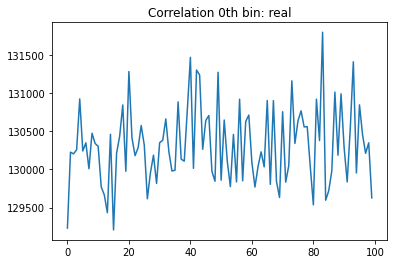

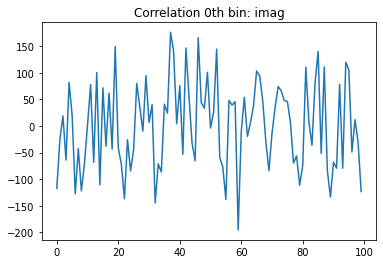

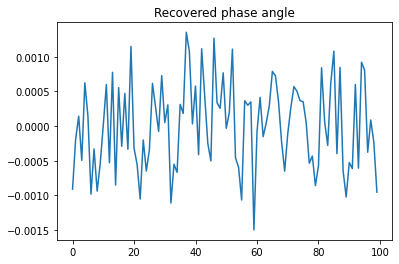

0.0006276651704596967
100


In [259]:
# Now let's try this over a few iterations and see what phase I recover:

signal=np.random.normal(0,1.0,(len(iteration_space),t_length)) +1.0j*np.random.normal(0,1.0,(len(iteration_space),t_length))
jit = np.exp(-1.0j*np.random.normal(0,0.1,(len(iteration_space),t_length)))

plt.title('Jitter phase angle')
plt.plot(np.angle(jit[0,:]))
plt.show()
print(np.std(jit[0,:]))
print(np.std(jit[:,0]))
# simple std recovers the input jitter phase


jitsig = signal*jit

plt.title('Phase angles')
plt.plot(np.angle(signal[0,:]),'b.',label='signal phase angle')
plt.plot(np.angle(jitsig[0,:]),'r.',label='jitter+signal phase angle')
plt.xlim(0,15)
plt.legend()
plt.show()

corr=np.fft.ifft(np.fft.fft(jitsig)*np.conjugate(np.fft.fft(signal)))
print(corr.shape)

plt.title('Correlation spectrum (65k long, zoomed)')
plt.plot(corr[0,:].real,label='real')
plt.plot(corr[0,:].imag,label='imag')
plt.legend()
plt.xlim(0,10)
plt.show()

plt.title('Correlation 0th bin: real')
plt.plot(corr[:,0].real)
plt.show()
plt.title('Correlation 0th bin: imag')
plt.plot(corr[:,0].imag)
plt.show()

phre = np.angle(corr[:,0])
plt.plot(phre)
plt.title('Recovered phase angle')
plt.show()
print(np.std(phre))
print(len(iteration_space))

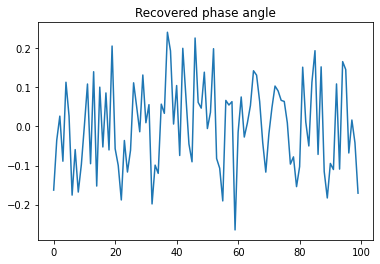

0.11254231611681259
100


In [268]:
# see if I can figure out how to get back a 0.1 jitter
rr = corr[:,0].real
ii = np.sqrt(t_length/2)*corr[:,0].imag
phre = np.arctan2(ii,rr)
plt.plot(phre)
plt.title('Recovered phase angle')
plt.show()
print(np.std(phre))
print(len(iteration_space))

In [8]:
###### WILL's CODE, slightly modified for fewer iterations

In [9]:
## 2) Looping through 1000 of same jitter to test noise properties for Kalyani's new metric:
#stop
## This run is 50 jitters, 30 gains [hyperbolic distribution], 10000 iterations, input power 0, 4 int periods...
## Select fixed params that dictate run properties:
fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=1.0
iteration_space=np.arange(50)
jitter_space=np.hstack((np.array([0]),np.linspace(1e-12,4e-9,50)))
gain_space=(np.linspace(0.05,2.0,30)**2.0)
#jitter_space=[0.7E-9,1.7E-9]
#gain_space=[0.12,0.79]

# Now add lag
#SOL=299792458.0  #m/s
#typdist=np.sqrt((100.0**2.0)+(175.0**2.0))
#FS_Lag=typdist/SOL
### How big should we expect our front-end lags to be?
#FE_Lag=100.0/(0.85*SOL)
#print("A reasonable estimate for the FS_Lag is {:.4f}us".format(1e6*FS_Lag))
#print(" --> This corresponds to a free-space lag of {:.4f}us".format(1e6*typdist/SOL))
#print("A reasonable estimate for the Total_Lag=FS_Lag+FE_Lag is {:.4f}us".format(1e6*(FS_Lag+FE_Lag)))




## Define parameter arrays that we want to pull out for each jitter we test:
input_phase=np.zeros((len(jitter_space),len(gain_space),len(iteration_space)))
## Unquantized (f) correlations:
nq_max_ind_auto=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_ind_cross=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_mag_auto_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_auto_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)

signal=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term_off=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))

for i,iteration in enumerate(iteration_space):
    for g,gain in enumerate(gain_space):
        f_signal=signal[i]
        f_signal_on=(gain*signal[i])+noise_term[i]
        f_signal_off=noise_term_off[i]
        for j,jitter in enumerate(jitter_space):
            print('Iteration:{}/{}, Gain:{}/{}, Jitter:{}/{}    '.format(i+1,len(iteration_space),g+1,len(gain_space),j+1,len(jitter_space)),end='\r')
            ## Draw a sample to populate the jitter array and construct index shift/phase:
            simtimearr=(np.ones(t_length)*(FS_Lag+FE_Lag))+np.random.normal(0,jitter,t_length)
            index_shift=int(np.nanmedian(Index_Shift_From_Time(simtimearr)))
            phase_rads=Phase_Shift_From_Time(simtimearr,fman)
            input_phase[j,g,i]=np.nanmean(phase_rads)
            phase_array=np.exp(-1.0j*phase_rads)
            #phase_array=np.exp(-1.0j*2.0*np.pi*phase_rads)
            ## create the f and q arrays:
            f_signal_on_ps=np.roll(phase_array*f_signal_on,index_shift)
            f_signal_off_ps=np.roll(phase_array*f_signal_off,index_shift)
            ## Select the scaling
            ## Perform correlations (unquantized):
            nq_auto_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal_on_ps)))
            nq_auto_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal_off_ps)))
            nq_cross_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal)))
            nq_cross_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal)))
            ## Populate loop auto variables (unquantized):
            nq_max_mag_auto_on[j,g,i]=nq_auto_corr_on_ps[0]
            nq_max_mag_auto_off[j,g,i]=nq_auto_corr_off_ps[0]
            nq_max_mag_cross_on[j,g,i]=nq_cross_corr_on_ps[0]
            nq_max_mag_cross_off[j,g,i]=nq_cross_corr_off_ps[0]                

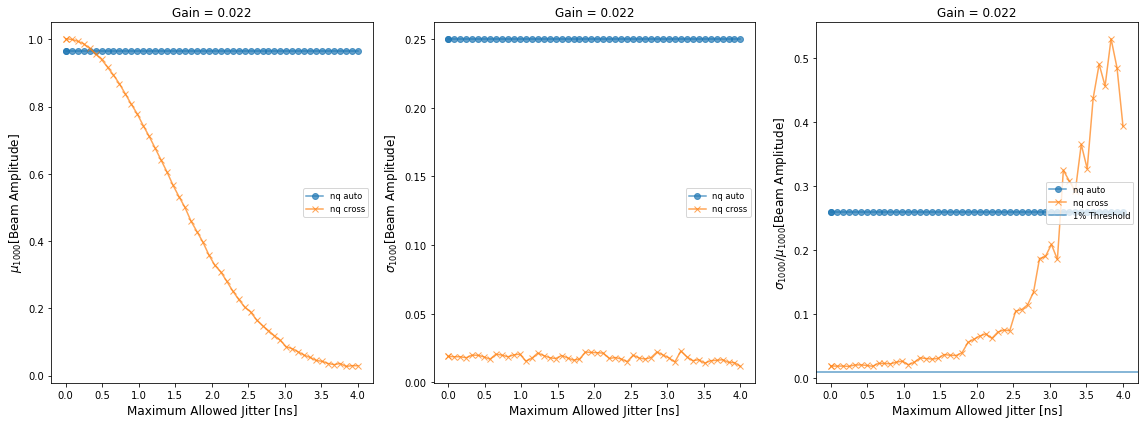

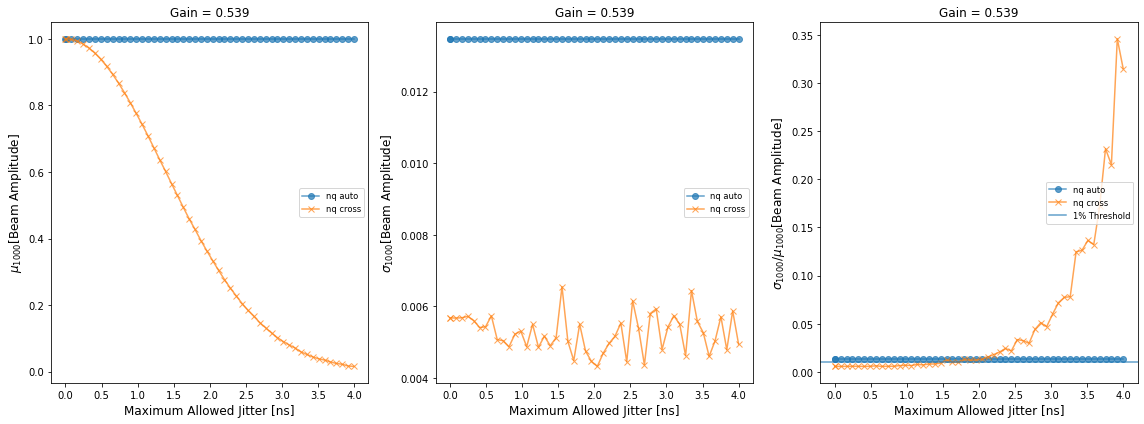

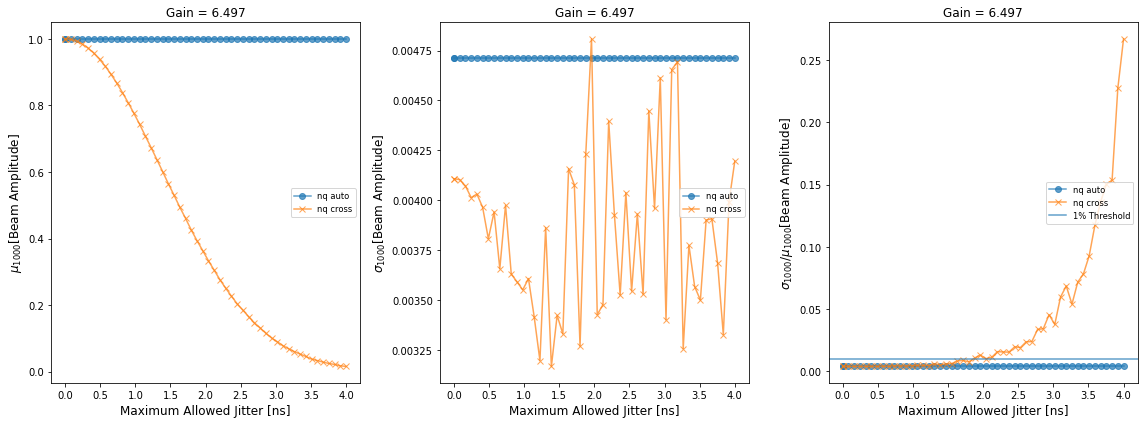

In [10]:
# Using Kalyani's recovered gain method:
for g in [5,12,23]:
    gain = gain_space[g]
    fig,[ax1,ax2,ax3]=subplots(nrows=1,ncols=3,figsize=(16,6))
    nq_a_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain_space[g]**2.0))
    nq_c_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain_space[g]**1.0))
    
    for k,ax in enumerate([ax1]):
        ax.set_title("Gain = {:.3f}".format(gain_space[g]*gain_space[g]),fontsize='large')
        nq_x=nq_a_norm*np.nanmean((np.abs(nq_max_mag_auto_on[:,g,:])-np.abs(nq_max_mag_auto_off[:,g,:])),axis=1)
        nq_y=nq_c_norm*np.nanmean(np.abs(nq_max_mag_cross_on[:,g,:]),axis=1)
        
        ax.plot(jitter_space*1e9,nq_x,'o-',alpha=0.7,label='nq auto')
        ax.plot(jitter_space*1e9,nq_y,'x-',alpha=0.7,label='nq cross')

        ax.set_ylabel("$\mu_{1000}$[Beam Amplitude]",fontsize='large')
        ax.set_xlabel('Maximum Allowed Jitter [ns]',fontsize='large')
        ax.legend(loc=5,fontsize='small')
    for k,ax in enumerate([ax2]):
        ax.set_title("Gain = {:.3f}".format(gain_space[g]*gain_space[g]),fontsize='large')
        nq_x=nq_a_norm*np.nanstd((np.abs(nq_max_mag_auto_on[:,g,:])-np.abs(nq_max_mag_auto_off[:,g,:])),axis=1)
        nq_y=nq_c_norm*np.nanstd(np.abs(nq_max_mag_cross_on[:,g,:]),axis=1)
    
        ax.plot(jitter_space*1e9,nq_x,'o-',alpha=0.7,label='nq auto')
        ax.plot(jitter_space*1e9,nq_y,'x-',alpha=0.7,label='nq cross')

        ax.set_ylabel("$\sigma_{1000}$[Beam Amplitude]",fontsize='large')
        ax.set_xlabel('Maximum Allowed Jitter [ns]',fontsize='large')
        ax.legend(loc=5,fontsize='small')
    for k,ax in enumerate([ax3]):
        ax.set_title("Gain = {:.3f}".format(gain_space[g]*gain_space[g]),fontsize='large')
        nq_x=np.nanstd((np.abs(nq_max_mag_auto_on[:,g,:])-np.abs(nq_max_mag_auto_off[:,g,:])),axis=1)/np.nanmean((np.abs(nq_max_mag_auto_on[:,g,:])-np.abs(nq_max_mag_auto_off[:,g,:])),axis=1)
        nq_y=np.nanstd(np.abs(nq_max_mag_cross_on[:,g,:]),axis=1)/np.nanmean(np.abs(nq_max_mag_cross_on[:,g,:]),axis=1)

        ax.plot(jitter_space*1e9,nq_x,'o-',alpha=0.7,label='nq auto')
        ax.plot(jitter_space*1e9,nq_y,'x-',alpha=0.7,label='nq cross')
        ax.axhline(0.01,alpha=0.7,label='1% Threshold')
        ax.set_ylabel("$\sigma_{1000}$/$\mu_{1000}$[Beam Amplitude]",fontsize='large')
        ax.set_xlabel('Maximum Allowed Jitter [ns]',fontsize='large')
        ax.legend(loc=5,fontsize='small')
    tight_layout()

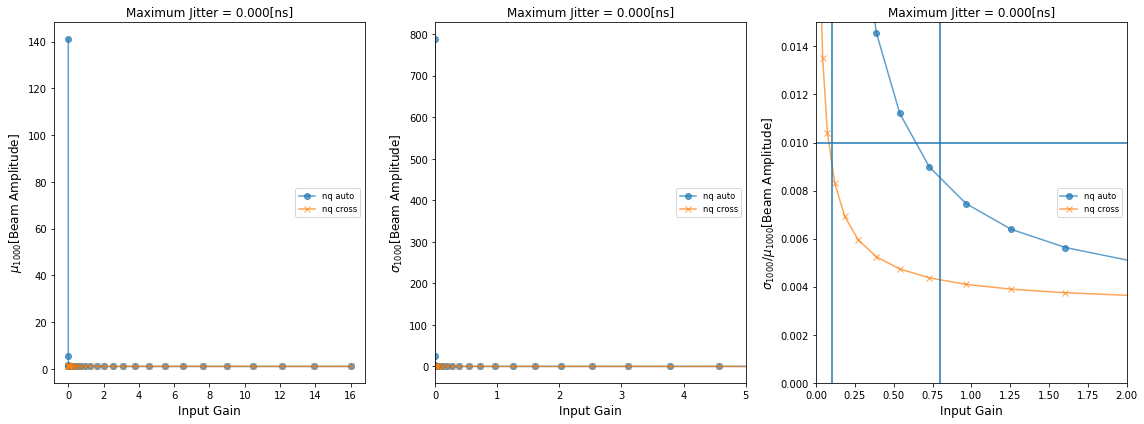

In [7]:
fig,[ax1,ax2,ax3]=subplots(nrows=1,ncols=3,figsize=(16,6))
for j in [0]:
    ## AX 1 Mean
    nq_a_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain_space[:]**2.0))
    nq_c_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain_space[:]))
   
    nq_x=nq_a_norm*np.nanmean((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)
    nq_y=nq_c_norm*np.nanmean(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)

    indlist=[0,100,200,300,400,500,600,700,800,999]
    #for bb,zz in enumerate(indlist[:-2]):
    #    nq_z=nq_a_norm*np.nanmean((np.abs(nq_max_mag_auto_on[j,:,indlist[bb]:indlist[bb+1]])-np.abs(nq_max_mag_auto_off[j,:,indlist[bb]:indlist[bb+1]])),axis=1)
    #    ax1.plot(gain_space,nq_z,'o-',alpha=0.7,label='nq auto {}'.format(indlist[bb]))
    ax1.plot(gain_space*gain_space,nq_x,'o-',alpha=0.7,label='nq auto')
    ax1.plot(gain_space*gain_space,nq_y,'x-',alpha=0.7,label='nq cross')
    ax1.set_ylabel("$\mu_{1000}$[Beam Amplitude]",fontsize='large')
    ## AX 2 STD
    nq_x=nq_a_norm*np.nanstd((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)
    nq_y=nq_c_norm*np.nanstd(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)
   
    ax2.plot(gain_space*gain_space,nq_x,'o-',alpha=0.7,label='nq auto')
    ax2.plot(gain_space*gain_space,nq_y,'x-',alpha=0.7,label='nq cross')

    ax2.set_xlim(0,5)
    #ax2.set_ylim(0.005,0.015)
    ax2.set_ylabel("$\sigma_{1000}$[Beam Amplitude]",fontsize='large')
    ## AX 3 STD/Mean
    nq_x=np.nanstd((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)/np.nanmean((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)
    nq_y=np.nanstd(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)/np.nanmean(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)
    
    ax3.plot(gain_space*gain_space,nq_x,'o-',alpha=0.7,label='nq auto')
    ax3.plot(gain_space*gain_space,nq_y,'x-',alpha=0.7,label='nq cross')

    ax3.axhline(0.01)
    ax3.axvline(0.1)
    ax3.axvline(0.8)
    ax3.set_xlim(0,2)
    ax3.set_ylim(0.000,0.015)
    ax3.set_ylabel("$\sigma_{1000}$/$\mu_{1000}$[Beam Amplitude]",fontsize='large')
    for ax in [ax1,ax2,ax3]:
        ax.set_title("Maximum Jitter = {:.3f}[ns]".format(1e9*jitter_space[j]),fontsize='large')
        ax.set_xlabel('Input Gain',fontsize='large')
        ax.legend(loc=5,fontsize='small')      
tight_layout()

0.003125


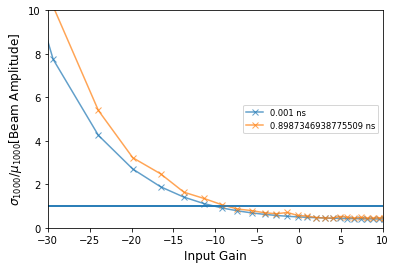

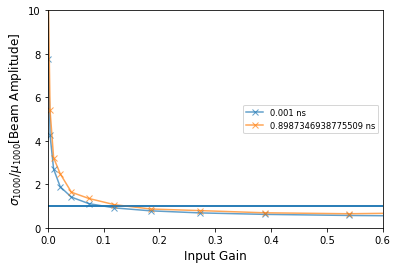

In [37]:
# Can I tell the difference between input gain and recovered jitter values?
# Kalyani's jitter: 0.8ns
# recovered jitte: 0.8ns / sqrt(65536)
print(0.8/np.sqrt(65536))

for j in [1,12]:
    indlist=[0,100,200,300,400,500,600,700,800,999]

    ## AX 3 STD/Mean
    nq_x=np.nanstd((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)/np.nanmean((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)
    nq_y=np.nanstd(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)/np.nanmean(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)
    
    #plt.plot(gain_space*gain_space,nq_x*100,'o-',alpha=0.7,label='nq auto')
    plt.plot(10*np.log10(gain_space*gain_space),nq_y*100,'x-',alpha=0.7,label=str(1e9*jitter_space[j])+' ns')

    plt.axhline(1.0)
    #plt.axvline(0.1)
    #plt.axvline(0.8)
    #plt.xlim(0,0.6)
    plt.xlim(-30,10)
    plt.ylim(0,10)
    plt.ylabel("$\sigma_{1000}$/$\mu_{1000}$[Beam Amplitude]",fontsize='large')
    #plt.title("Maximum Jitter = {:.3f}[ns]".format(1e9*jitter_space[j]),fontsize='large')
    plt.xlabel('Input Gain',fontsize='large')
    plt.legend(loc=5,fontsize='small')      
plt.show()

for j in [1,12]:
    indlist=[0,100,200,300,400,500,600,700,800,999]

    ## AX 3 STD/Mean
    nq_x=np.nanstd((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)/np.nanmean((np.abs(nq_max_mag_auto_on[j,:,:])-np.abs(nq_max_mag_auto_off[j,:,:])),axis=1)
    nq_y=np.nanstd(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)/np.nanmean(np.abs(nq_max_mag_cross_on[j,:,:]),axis=1)
    
    #plt.plot(gain_space*gain_space,nq_x*100,'o-',alpha=0.7,label='nq auto')
    plt.plot(gain_space*gain_space,nq_y*100,'x-',alpha=0.7,label=str(1e9*jitter_space[j])+' ns')

    plt.axhline(1.0)
    #plt.axvline(0.1)
    #plt.axvline(0.8)
    plt.xlim(0,0.6)
    #plt.xlim(-30,10)
    plt.ylim(0,10)
    plt.ylabel("$\sigma_{1000}$/$\mu_{1000}$[Beam Amplitude]",fontsize='large')
    #plt.title("Maximum Jitter = {:.3f}[ns]".format(1e9*jitter_space[j]),fontsize='large')
    plt.xlabel('Input Gain',fontsize='large')
    plt.legend(loc=5,fontsize='small')      
plt.show()

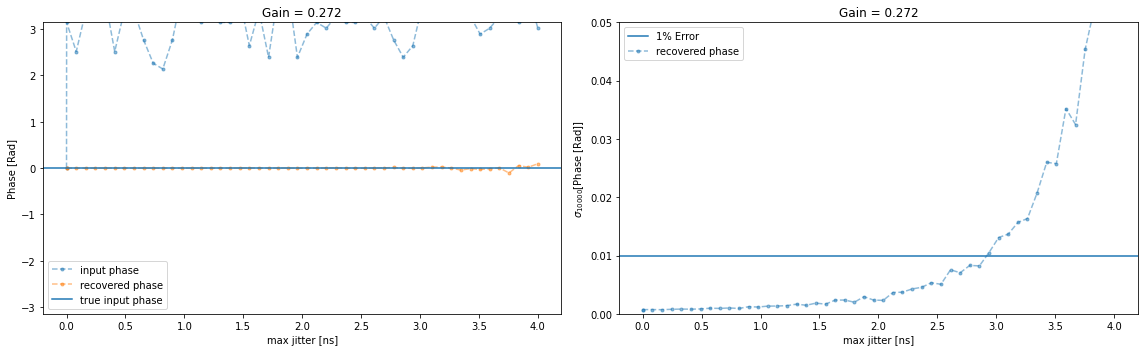

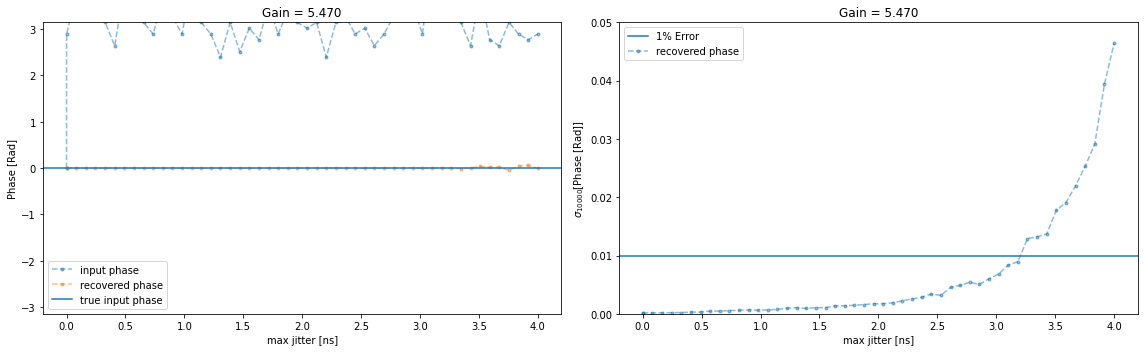

In [11]:
for g in [10,22]:
    gain = gain_space[g]
    fig,[ax1,ax2]=subplots(nrows=1,ncols=2,figsize=(16,5))
    ax1.plot(jitter_space*1e9,np.nanmean(input_phase[:,g,:]%(2*np.pi),axis=1),'.--',alpha=0.5,label='input phase')
    ax1.plot(jitter_space*1e9,np.nanmean(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1),'.--',alpha=0.5,label='recovered phase')
    ax1.set_ylim(-np.pi,np.pi)
    ax2.set_ylim(0.0,0.05)
    ax1.axhline(input_phase[0,0,0]%(2*np.pi),label='true input phase')    
    ax2.axhline(0.01,label='1% Error')    
    ax2.plot(jitter_space*1e9,np.nanstd(-np.angle(nq_max_mag_cross_on[:,g,:]),axis=1)/(2.0*np.pi),'.--',alpha=0.5,label='recovered phase')
    for ax in [ax1,ax2]:
        ax.set_title("Gain = {:.3f}".format(gain*gain))
        ax.set_xlabel('max jitter [ns]')
        ax.legend()

    ax1.set_ylabel('Phase [Rad]')
    ax2.set_ylabel('$\sigma_{10000}$[Phase [Rad]]')

    tight_layout()
    

In [9]:
for g in [5,12,23]:
    gain = gain_space[g]
    for j in [10,21]:
        jit = jitter_space[j]
        nq_a_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain**2.0))
        nq_c_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain))
    
        nq_x=np.nanstd((np.abs(nq_max_mag_auto_on[j,g,:])-np.abs(nq_max_mag_auto_off[j,g,:])))/np.nanmean((np.abs(nq_max_mag_auto_on[j,g,:])-np.abs(nq_max_mag_auto_off[j,g,:])))
        nq_y=np.nanstd(np.abs(nq_max_mag_cross_on[j,g,:]))/np.nanmean(np.abs(nq_max_mag_cross_on[j,g,:]))

        print('gain ', gain, 'jitter ', jit, ', auto, cross gain %: ',100*nq_x, 100*nq_y)

gain  0.14915576694411412 jitter  7.355102040816326e-10 , auto, cross gain %:  21.157389877334715 2.1297072256587284
gain  0.14915576694411412 jitter  1.6332448979591837e-09 , auto, cross gain %:  21.157389877334698 4.000649102101099
gain  0.7342717003567182 jitter  7.355102040816326e-10 , auto, cross gain %:  1.1213470923256452 0.5356898081736611
gain  0.7342717003567182 jitter  1.6332448979591837e-09 , auto, cross gain %:  1.1213470923256463 0.9819588214653859
gain  2.5489774078478002 jitter  7.355102040816326e-10 , auto, cross gain %:  0.37150031416229695 0.3692599564463356
gain  2.5489774078478002 jitter  1.6332448979591837e-09 , auto, cross gain %:  0.3715003141622969 0.6599792453388755


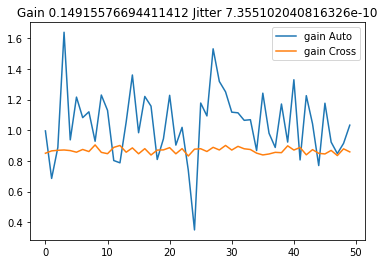

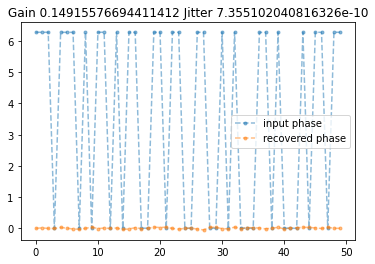

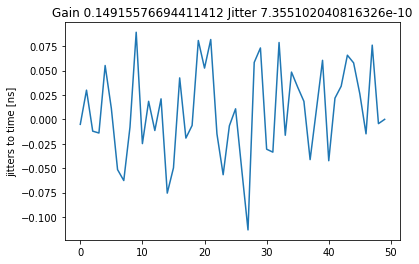

0.04638553493159349


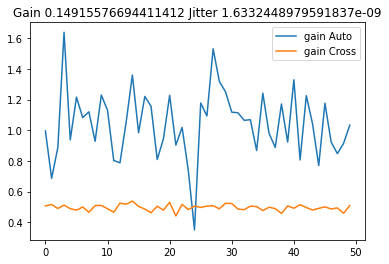

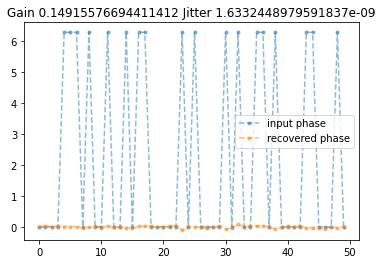

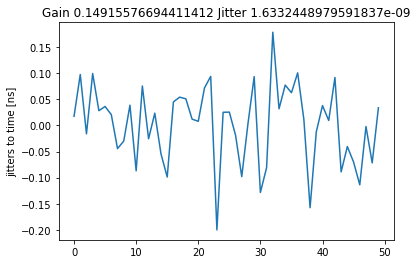

0.07490146248433621


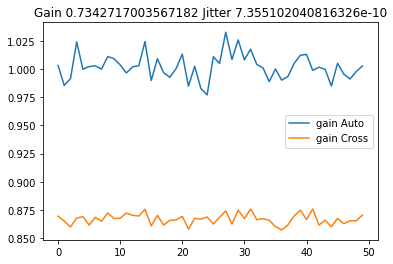

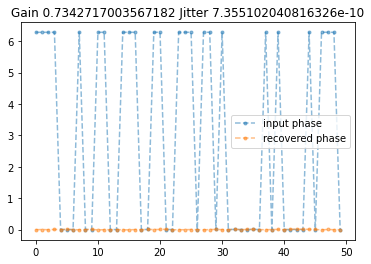

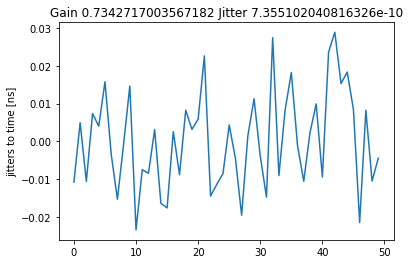

0.012983761683674875


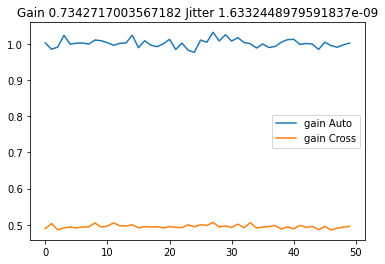

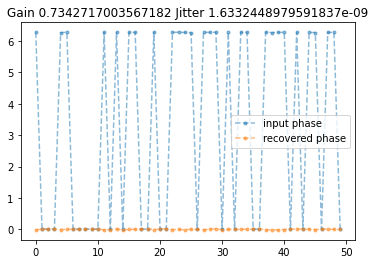

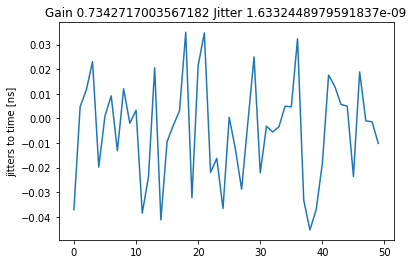

0.02086301753113056


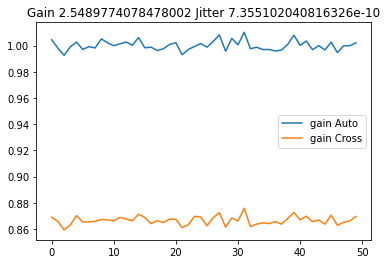

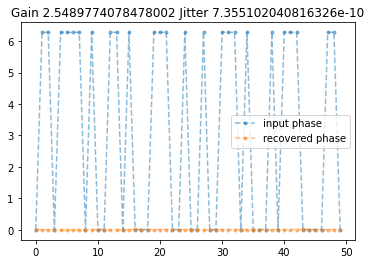

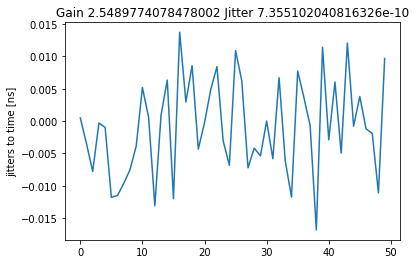

0.00739623143974907


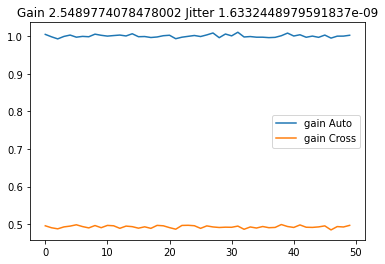

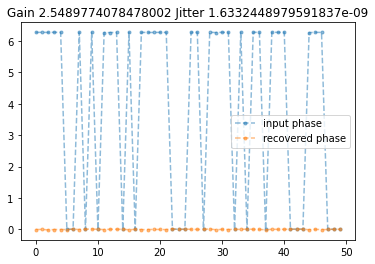

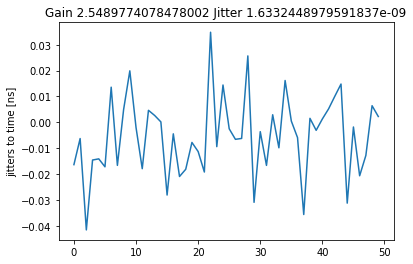

0.015353725641203892


In [10]:
## Let's plot what happens over the iterations:

for g in [5,12,23]:
    gain = gain_space[g]
    for j in [10,21]:
        jit = jitter_space[j]
        nq_a_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain**2.0))
        nq_c_norm=1.0/(2*(inputpower**2.0)*(t_length)*(gain))
    
        nq_aa=nq_a_norm*(np.abs(nq_max_mag_auto_on[j,g,:])-np.abs(nq_max_mag_auto_off[j,g,:]))
        nq_ca=nq_c_norm*(np.abs(nq_max_mag_cross_on[j,g,:]))

        plt.plot(nq_aa, label='gain Auto')
        plt.plot(nq_ca, label='gain Cross')
        plt.title('Gain '+str(gain)+' Jitter '+str(jit))
        plt.legend()
        plt.show()

        ip = input_phase[j,g,:]%(2*np.pi)
        rp = -np.angle(nq_max_mag_cross_on[j,g,:])

        plt.plot(ip,'.--',alpha=0.5,label='input phase')
        plt.plot(rp,'.--',alpha=0.5,label='recovered phase')
        plt.title('Gain '+str(gain)+' Jitter '+str(jit))
        plt.legend()
        plt.show()

        times = 1E9* rp / 2*np.pi / fman
        plt.plot(times)
        plt.ylabel('jitters to time [ns]')
        plt.title('Gain '+str(gain)+' Jitter '+str(jit))
        plt.show()
        print(np.std(times))

In [11]:
###### JUST ONE GAIN, ONE JITTER, MANY ITERATIONS to do quick checks

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=1.0
iteration_space=np.arange(100)


# pick your gains, jitters
jitter_space=[0.7E-9,1.2E-9]
gain_space=[0.15,0.73,2.5]
g = 0
j = 0
gain = gain_space[g]
jitter = jitter_space[j]

# Now add lag
#SOL=299792458.0  #m/s
#typdist=np.sqrt((100.0**2.0)+(175.0**2.0))
#FS_Lag=typdist/SOL
### How big should we expect our front-end lags to be?
#FE_Lag=100.0/(0.85*SOL)
#print("A reasonable estimate for the FS_Lag is {:.4f}us".format(1e6*FS_Lag))
#print(" --> This corresponds to a free-space lag of {:.4f}us".format(1e6*typdist/SOL))
#print("A reasonable estimate for the Total_Lag=FS_Lag+FE_Lag is {:.4f}us".format(1e6*(FS_Lag+FE_Lag)))


## Define parameter arrays that we want to pull out for each jitter we test:
input_phase=np.zeros((len(jitter_space),len(gain_space),len(iteration_space)))
## Unquantized (f) correlations:
nq_max_ind_auto=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_ind_cross=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(int)
nq_max_mag_auto_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_auto_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_on=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)
nq_max_mag_cross_off=np.zeros((len(jitter_space),len(gain_space),len(iteration_space))).astype(complex)

signal=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term_off=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))

for i,iteration in enumerate(iteration_space):
            f_signal=signal[i]
            f_signal_on=(gain*signal[i])+noise_term[i]
            f_signal_off=noise_term_off[i]
            
            print('Iteration:{}/{}, Gain:{}/{}, Jitter:{}/{}    '.format(i+1,len(iteration_space),g+1,len(gain_space),j+1,len(jitter_space)),end='\r')
            ## Draw a sample to populate the jitter array and construct index shift/phase:
            simtimearr=(np.ones(t_length)*(FS_Lag+FE_Lag))+np.random.normal(0,jitter,t_length)
            index_shift=int(np.nanmedian(Index_Shift_From_Time(simtimearr)))
            phase_rads=Phase_Shift_From_Time(simtimearr,fman)
            input_phase[j,g,i]=np.nanmean(phase_rads)
            phase_array=np.exp(-1.0j*phase_rads)
            #phase_array=np.exp(-1.0j*2.0*np.pi*phase_rads)
            ## create the f and q arrays:
            f_signal_on_ps=np.roll(phase_array*f_signal_on,index_shift)
            f_signal_off_ps=np.roll(phase_array*f_signal_off,index_shift)
            ## Select the scaling
            ## Perform correlations (unquantized):
            nq_auto_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal_on_ps)))
            nq_auto_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal_off_ps)))
            nq_cross_corr_on_ps=np.fft.ifft(np.fft.fft(f_signal_on_ps)*np.conjugate(np.fft.fft(f_signal)))
            nq_cross_corr_off_ps=np.fft.ifft(np.fft.fft(f_signal_off_ps)*np.conjugate(np.fft.fft(f_signal)))
            ## Populate loop auto variables (unquantized):
            nq_max_mag_auto_on[j,g,i]=nq_auto_corr_on_ps[0]
            nq_max_mag_auto_off[j,g,i]=nq_auto_corr_off_ps[0]
            nq_max_mag_cross_on[j,g,i]=nq_cross_corr_on_ps[0]
            nq_max_mag_cross_off[j,g,i]=nq_cross_corr_off_ps[0]                

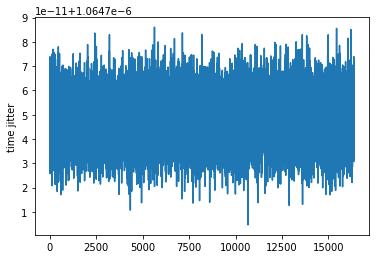

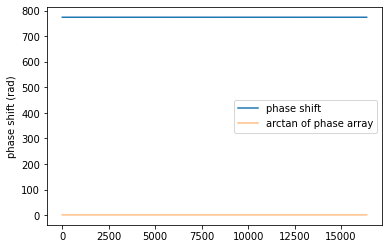

774.0750623986037 1.2432696155145404


In [12]:
###### JUST ONE GAIN, ONE JITTER, ONE ITERATION to do quick checks
def Phase_Shift_From_Time(time_array,frequency):
    return time_array*frequency#%(2*np.pi)

fman=727e6 #select freq
t_length=16384#65536 # 4*16384
inputpower=1.0
iteration_space=np.arange(1)
i=0
g=0
j=0
gain = 0.12
jitter=1E-11

SOL=299792458.0  #m/s
typdist=np.sqrt((100.0**2.0)+(175.0**2.0))
FS_Lag=typdist/SOL
### How big should we expect our front-end lags to be?
FE_Lag=100.0/(0.85*SOL)

## Define parameter arrays that we want to pull out for each jitter we test:

signal=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))
noise_term_off=np.random.normal(0,inputpower,(len(iteration_space),t_length))+(1.0j*np.random.normal(0,inputpower,(len(iteration_space),t_length)))


# For my first try, skip all the iterations and just compute the gain and phase with one jitter value, once
        
simtimearr=(np.ones(t_length)*(FS_Lag+FE_Lag))+np.random.normal(0,jitter,t_length)
index_shift=int(np.nanmedian(Index_Shift_From_Time(simtimearr)))

phase_rads=Phase_Shift_From_Time(simtimearr,fman) # jitter, time
phase_array=np.exp(1.0j*phase_rads) # jitter, time  

plt.plot(simtimearr)
plt.ylabel('time jitter')
plt.show()

plt.plot(phase_rads,label='phase shift')
plt.plot(np.angle(phase_array),alpha=0.5,label='arctan of phase array')
plt.ylabel('phase shift (rad)')
plt.legend()
plt.show()

j = 1
print(phase_rads[j], np.angle(phase_array[j]))